# Detector Comparison Overview

This notebook implements all the detectors on a simple 2D example, plots their level sets, and evaluates the results.

## Imports

In [1]:
import time

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import cristal as cst

## Parameters

In [2]:
n = 3 # Degree of the CF
n_list = list(range(2, 7)) # Degrees for the CG detectors: from 2 to 6
N = 5_000 # Number of samples

## Data

In [3]:
data = cst.evaluation.data.make_uniform_square(n_samples=N)

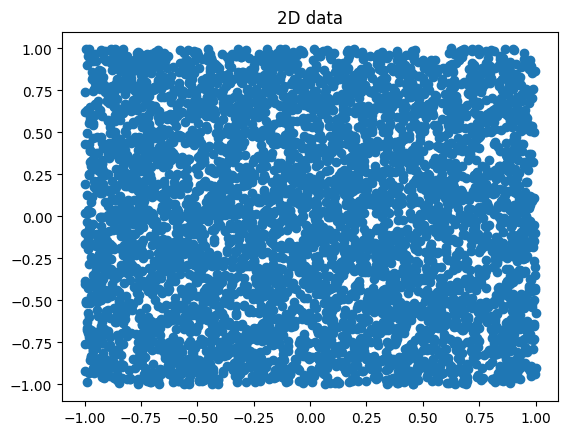

In [4]:
plt.figure()
plt.title("2D data")
plt.scatter(data[:, 0], data[:, 1])
plt.show()

## Create configurations

For details about configuration parameters and their default values, please consult the [official API documentation](https://fgrivet.github.io/CRISTAL/API/cristal.config.html#).

In this example, we'll use the default configuration values, with one exception: we'll set the `backend` parameter to `torch` instead of `numpy` to achieve better performance.

### Dynamic

The dynamic detectors are the detectors that compute the moment matrix once and for all, like `DyCF`, `DyCG`, `KernelCF`, and `KernelCG`.

In [5]:
dynamic_config = cst.config.DynamicDetectorConfig(backend="torch")

### Static

The static detectors are the detectors that need to compute the moment matrix for each query sample, like `UCG`, `UCG`, `NeedleCF`, and `NeedleCG`.

In [6]:
static_config = cst.config.StaticDetectorConfig(backend="torch")

## Create and fit the detectors

### Dynamic

#### Dynamical

In [7]:
dycf = cst.DyCF(n, config=dynamic_config)
t_start_fit_dycf = time.perf_counter()
dycf.fit(data)
t_end_fit_dycf = time.perf_counter()


dycg = cst.DyCG(n_list, config=dynamic_config)
t_start_fit_dycg = time.perf_counter()
dycg.fit(data)
t_end_fit_dycg = time.perf_counter()

#### Kernel-based

In [8]:
kernel_cf = cst.KernelCF(n, config=dynamic_config)
t_start_fit_kernel_cf = time.perf_counter()
kernel_cf.fit(data)
t_end_fit_kernel_cf = time.perf_counter()

kernel_cg = cst.KernelCG(n_list, config=dynamic_config, kernel="linear")
t_start_fit_kernel_cg = time.perf_counter()
kernel_cg.fit(data)
t_end_fit_kernel_cg = time.perf_counter()

> ⚠️ **Important Note:**
> KernelCG only supports the `linear` kernel. This is because with the default `rbf` kernel, scores are independent of the Christoffel Function degree `n`, while CG detectors rely on score growth relative to `n`.

### Static

#### Univariate

In [9]:
ucf = cst.UCF(n, config=static_config)
t_start_fit_ucf = time.perf_counter()
ucf.fit(data)
t_end_fit_ucf = time.perf_counter()


ucg = cst.UCG(n_list, config=static_config)
t_start_fit_ucg = time.perf_counter()
ucg.fit(data)
t_end_fit_ucg = time.perf_counter()

#### Kro&#x00F2; Lubinski

In [10]:
needle_cf = cst.NeedleCF(n, config=static_config)
t_start_fit_needle_cf = time.perf_counter()
needle_cf.fit(data)
t_end_fit_needle_cf = time.perf_counter()


needle_cg = cst.NeedleCG(n_list, config=static_config)
t_start_fit_needle_cg = time.perf_counter()
needle_cg.fit(data)
t_end_fit_needle_cg = time.perf_counter()

## Summary

In [11]:
methods_fit_times = {
    "DyCF": {"t_start": t_start_fit_dycf, "t_end": t_end_fit_dycf},
    "DyCG": {"t_start": t_start_fit_dycg, "t_end": t_end_fit_dycg},
    "KernelCF": {"t_start": t_start_fit_kernel_cf, "t_end": t_end_fit_kernel_cf},
    "KernelCG": {"t_start": t_start_fit_kernel_cg, "t_end": t_end_fit_kernel_cg},
    "UCF": {"t_start": t_start_fit_ucf, "t_end": t_end_fit_ucf},
    "UCG": {"t_start": t_start_fit_ucg, "t_end": t_end_fit_ucg},
    "NeedleCF": {"t_start": t_start_fit_needle_cf, "t_end": t_end_fit_needle_cf},
    "NeedleCG": {"t_start": t_start_fit_needle_cg, "t_end": t_end_fit_needle_cg}
}

elapsed_fit_times_str = [f"{v['t_end'] - v['t_start']:.5g} s" for v in methods_fit_times.values()]

fit_times_table = f"""
<table>
  <tr>
    <th></th>
    <th colspan="4" style="text-align:center;">Dynamic</th>
    <th colspan="4" style="text-align:center;">Static</th>
  </tr>
  <tr>
    <th style="text-align:center;">Method</th>
    {"".join(f'<th style="text-align:center;">{name}</th>' for name in methods_fit_times.keys())}
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Fitting Time</strong></td>
    {"".join(f'<td style="text-align:center;">{t}</td>' for t in elapsed_fit_times_str)}
  </tr>
</table>
"""
display(Markdown(fit_times_table))


<table>
  <tr>
    <th></th>
    <th colspan="4" style="text-align:center;">Dynamic</th>
    <th colspan="4" style="text-align:center;">Static</th>
  </tr>
  <tr>
    <th style="text-align:center;">Method</th>
    <th style="text-align:center;">DyCF</th><th style="text-align:center;">DyCG</th><th style="text-align:center;">KernelCF</th><th style="text-align:center;">KernelCG</th><th style="text-align:center;">UCF</th><th style="text-align:center;">UCG</th><th style="text-align:center;">NeedleCF</th><th style="text-align:center;">NeedleCG</th>
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Fitting Time</strong></td>
    <td style="text-align:center;">0.014401 s</td><td style="text-align:center;">0.011003 s</td><td style="text-align:center;">3.6977 s</td><td style="text-align:center;">4.3626 s</td><td style="text-align:center;">0.0003161 s</td><td style="text-align:center;">0.000539 s</td><td style="text-align:center;">0.0003025 s</td><td style="text-align:center;">0.0001761 s</td>
  </tr>
</table>


## Compute the scores

### Dynamic

#### Dynamical

In [12]:
t_start_score_dycf = time.perf_counter()
dycf_scores = dycf.score_samples(data)
t_end_score_dycf = time.perf_counter()


t_start_score_dycg = time.perf_counter()
dycg_scores = dycg.score_samples(data)
t_end_score_dycg = time.perf_counter()

#### Kernel-based

In [13]:
t_start_score_kernel_cf = time.perf_counter()
kernel_cf_scores = kernel_cf.score_samples(data)
t_end_score_kernel_cf = time.perf_counter()


t_start_score_kernel_cg = time.perf_counter()
kernel_cg_scores = kernel_cg.score_samples(data)
t_end_score_kernel_cg = time.perf_counter()

### Static

#### Univariate

In [14]:
t_start_score_ucf = time.perf_counter()
ucf_scores = ucf.score_samples(data)
t_end_score_ucf = time.perf_counter()


t_start_score_ucg = time.perf_counter()
ucg_scores = ucg.score_samples(data)
t_end_score_ucg = time.perf_counter()

#### Kro&#x00F2; Lubinski

In [15]:
t_start_score_needle_cf = time.perf_counter()
needle_cf_scores = needle_cf.score_samples(data)
t_end_score_needle_cf = time.perf_counter()


t_start_score_needle_cg = time.perf_counter()
needle_cg_scores = needle_cg.score_samples(data)
t_end_score_needle_cg = time.perf_counter()

## Summary

In [16]:
methods_score_times = {
    "DyCF": {"t_start": t_start_score_dycf, "t_end": t_end_score_dycf},
    "DyCG": {"t_start": t_start_score_dycg, "t_end": t_end_score_dycg},
    "KernelCF": {"t_start": t_start_score_kernel_cf, "t_end": t_end_score_kernel_cf},
    "KernelCG": {"t_start": t_start_score_kernel_cg, "t_end": t_end_score_kernel_cg},
    "UCF": {"t_start": t_start_score_ucf, "t_end": t_end_score_ucf},
    "UCG": {"t_start": t_start_score_ucg, "t_end": t_end_score_ucg},
    "NeedleCF": {"t_start": t_start_score_needle_cf, "t_end": t_end_score_needle_cf},
    "NeedleCG": {"t_start": t_start_score_needle_cg, "t_end": t_end_score_needle_cg}
}

elapsed_score_times_str = [f"{v['t_end'] - v['t_start']:.5g} s" for v in methods_score_times.values()]

fit_times_table.split("\n")[:-2]
score_times_table = f"""
<table>
  <tr>
    <th></th>
    <th colspan="4" style="text-align:center;">Dynamic</th>
    <th colspan="4" style="text-align:center;">Static</th>
  </tr>
  <tr>
    <th style="text-align:center;">Method</th>
    {"".join(f'<th style="text-align:center;">{name}</th>' for name in methods_score_times.keys())}
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Scoring Time</strong></td>
    {"".join(f'<td style="text-align:center;">{t}</td>' for t in elapsed_score_times_str)}
  </tr>
</table>
"""
display(Markdown(score_times_table))


<table>
  <tr>
    <th></th>
    <th colspan="4" style="text-align:center;">Dynamic</th>
    <th colspan="4" style="text-align:center;">Static</th>
  </tr>
  <tr>
    <th style="text-align:center;">Method</th>
    <th style="text-align:center;">DyCF</th><th style="text-align:center;">DyCG</th><th style="text-align:center;">KernelCF</th><th style="text-align:center;">KernelCG</th><th style="text-align:center;">UCF</th><th style="text-align:center;">UCG</th><th style="text-align:center;">NeedleCF</th><th style="text-align:center;">NeedleCG</th>
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Scoring Time</strong></td>
    <td style="text-align:center;">0.0091749 s</td><td style="text-align:center;">0.033829 s</td><td style="text-align:center;">2.473 s</td><td style="text-align:center;">9.5492 s</td><td style="text-align:center;">0.57476 s</td><td style="text-align:center;">1.0777 s</td><td style="text-align:center;">0.80282 s</td><td style="text-align:center;">1.8162 s</td>
  </tr>
</table>


In [17]:
all_times_table = "\n".join(fit_times_table.split("\n")[:-2] + score_times_table.split("\n")[-6:])
display(Markdown(all_times_table))


<table>
  <tr>
    <th></th>
    <th colspan="4" style="text-align:center;">Dynamic</th>
    <th colspan="4" style="text-align:center;">Static</th>
  </tr>
  <tr>
    <th style="text-align:center;">Method</th>
    <th style="text-align:center;">DyCF</th><th style="text-align:center;">DyCG</th><th style="text-align:center;">KernelCF</th><th style="text-align:center;">KernelCG</th><th style="text-align:center;">UCF</th><th style="text-align:center;">UCG</th><th style="text-align:center;">NeedleCF</th><th style="text-align:center;">NeedleCG</th>
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Fitting Time</strong></td>
    <td style="text-align:center;">0.014401 s</td><td style="text-align:center;">0.011003 s</td><td style="text-align:center;">3.6977 s</td><td style="text-align:center;">4.3626 s</td><td style="text-align:center;">0.0003161 s</td><td style="text-align:center;">0.000539 s</td><td style="text-align:center;">0.0003025 s</td><td style="text-align:center;">0.0001761 s</td>
  </tr>
  <tr>
    <td style="text-align:center;"><strong>Scoring Time</strong></td>
    <td style="text-align:center;">0.0091749 s</td><td style="text-align:center;">0.033829 s</td><td style="text-align:center;">2.473 s</td><td style="text-align:center;">9.5492 s</td><td style="text-align:center;">0.57476 s</td><td style="text-align:center;">1.0777 s</td><td style="text-align:center;">0.80282 s</td><td style="text-align:center;">1.8162 s</td>
  </tr>
</table>


## Plot the scores

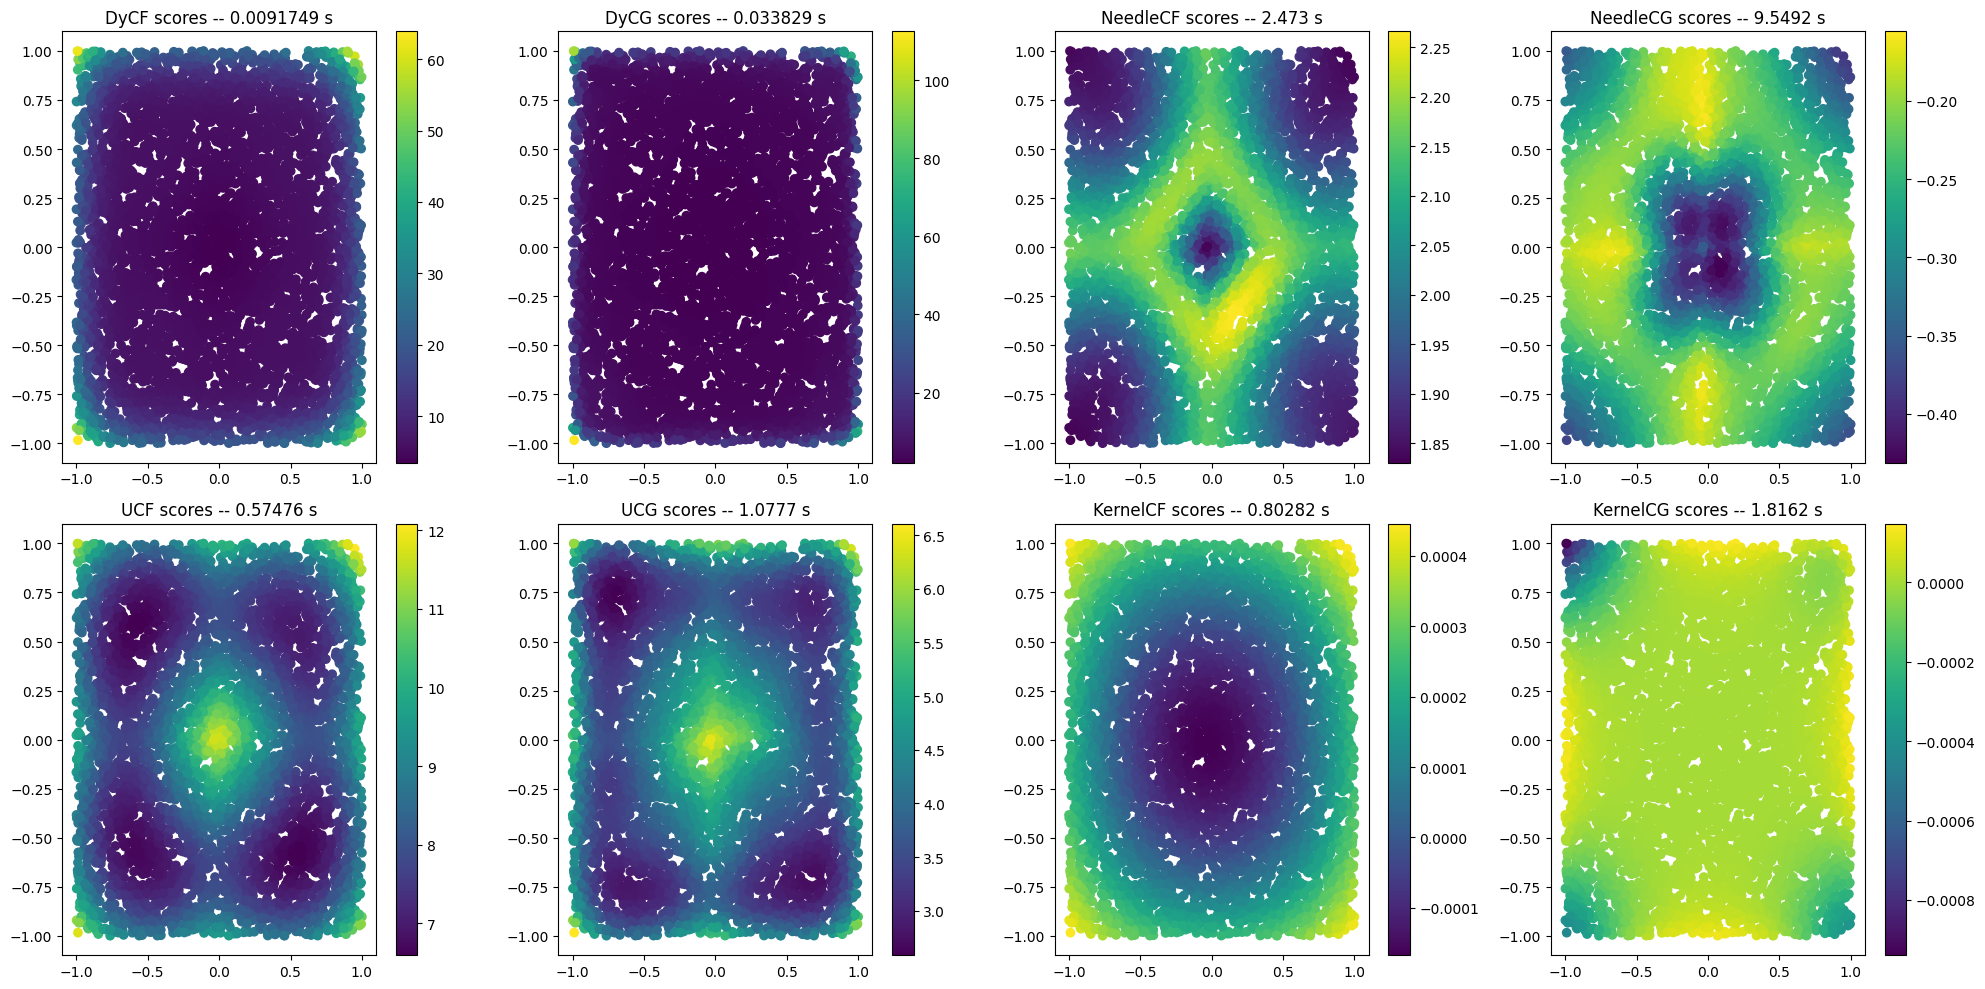

In [18]:
cmap = "viridis"
plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
plt.title(f"DyCF scores -- {elapsed_score_times_str[0]}")
plt.scatter(data[:, 0], data[:, 1], c=dycf_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 2)
plt.title(f"DyCG scores -- {elapsed_score_times_str[1]}")
plt.scatter(data[:, 0], data[:, 1], c=dycg_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 3)
plt.title(f"NeedleCF scores -- {elapsed_score_times_str[2]}")
plt.scatter(data[:, 0], data[:, 1], c=needle_cf_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 4)
plt.title(f"NeedleCG scores -- {elapsed_score_times_str[3]}")
plt.scatter(data[:, 0], data[:, 1], c=needle_cg_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 5)
plt.title(f"UCF scores -- {elapsed_score_times_str[4]}")
plt.scatter(data[:, 0], data[:, 1], c=ucf_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 6)
plt.title(f"UCG scores -- {elapsed_score_times_str[5]}")
plt.scatter(data[:, 0], data[:, 1], c=ucg_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 7)
plt.title(f"KernelCF scores -- {elapsed_score_times_str[6]}")
plt.scatter(data[:, 0], data[:, 1], c=kernel_cf_scores, cmap=cmap)
plt.colorbar()
plt.subplot(2, 4, 8)
plt.title(f"KernelCG scores -- {elapsed_score_times_str[7]}")
plt.scatter(data[:, 0], data[:, 1], c=kernel_cg_scores, cmap=cmap)
plt.colorbar()
plt.tight_layout()
plt.show()

## Plot level sets

> ⚠️ **Important Note:**
> `plot_levelset` and `plot_boundary` functions only work with 2D data. 

In [19]:
n_x1 = 100 # Number of points for grid evaluation along the first axis
n_x2 = 100 # Number of points for grid evaluation along the second axis
percentiles = [1, 5, 10, 25, 50, 75, 90] # Level sets percentiles to show

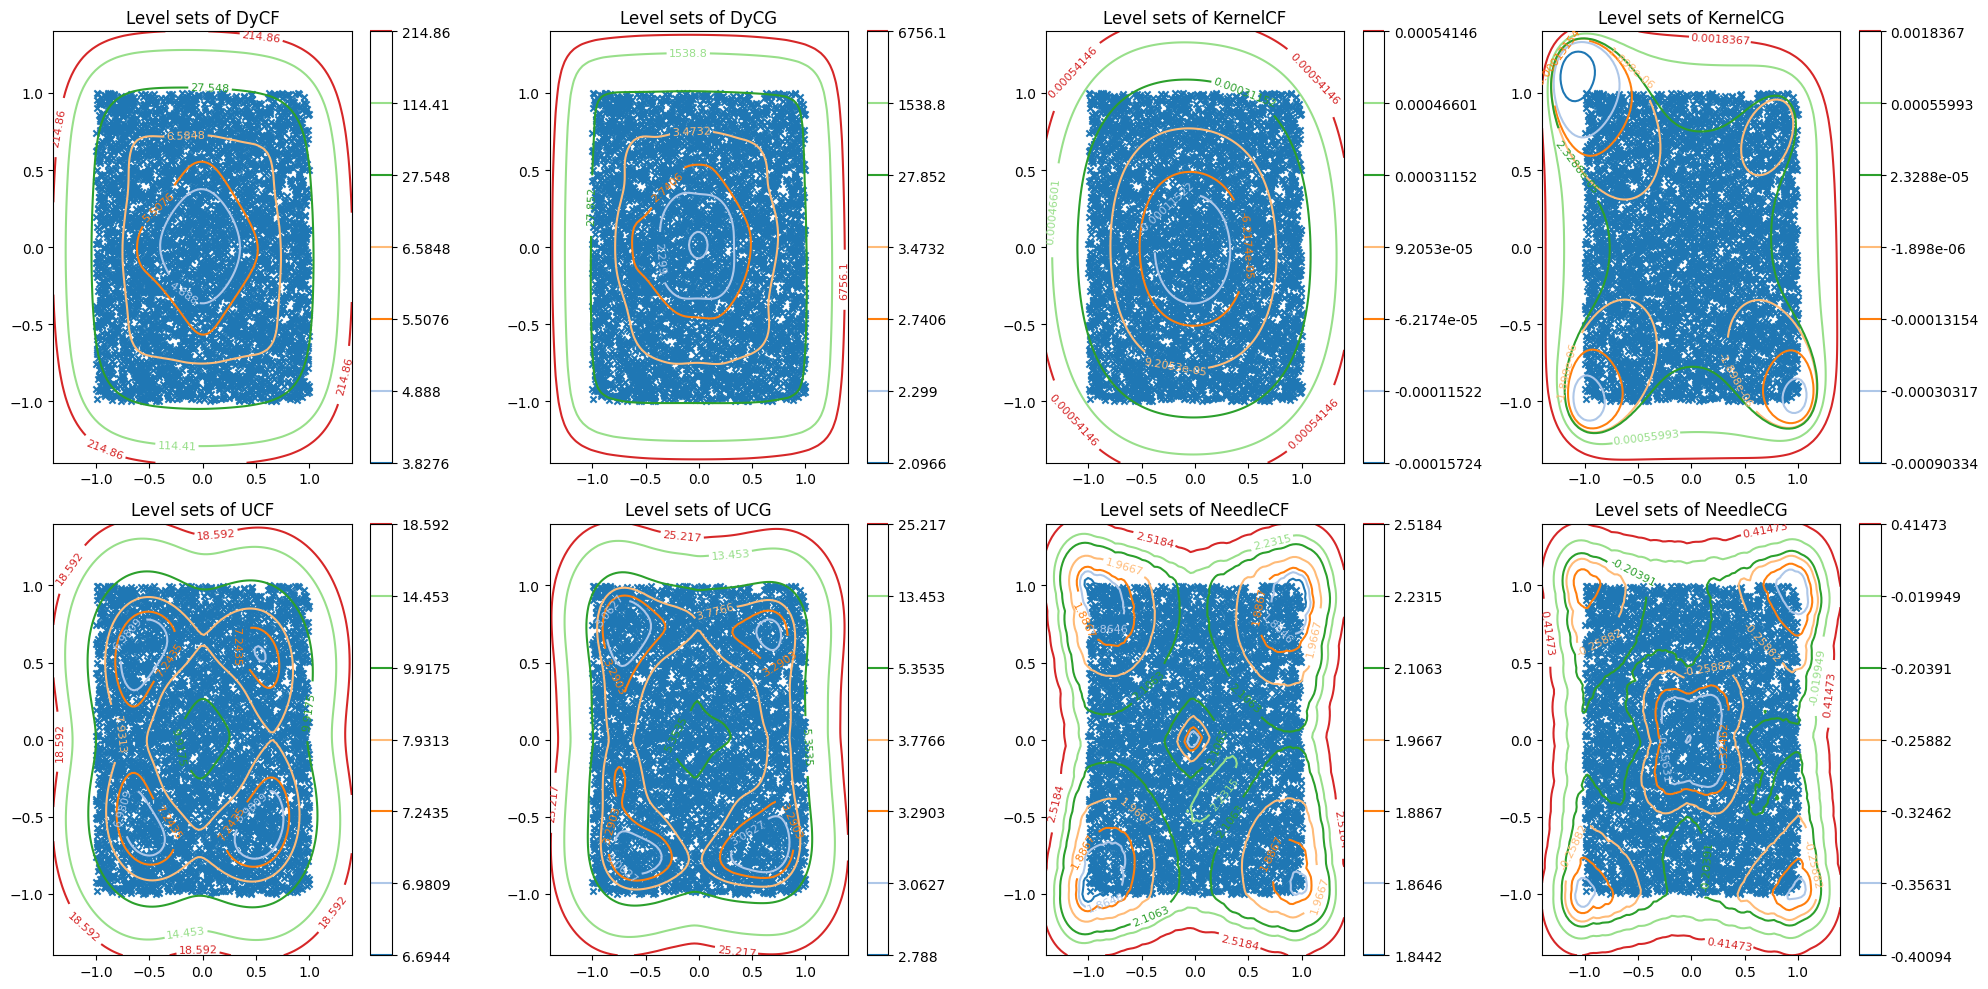

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
dycf.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[0, 0], show=False, close=False)
axes[0, 0].set_title("Level sets of DyCF")
dycg.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[0, 1], show=False, close=False)
axes[0, 1].set_title("Level sets of DyCG")
kernel_cf.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[0, 2], show=False, close=False)
axes[0, 2].set_title("Level sets of KernelCF")
kernel_cg.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[0, 3], show=False, close=False)
axes[0, 3].set_title("Level sets of KernelCG")
ucf.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[1, 0], show=False, close=False)
axes[1, 0].set_title("Level sets of UCF")
ucg.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[1, 1], show=False, close=False)
axes[1, 1].set_title("Level sets of UCG")
needle_cf.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[1, 2], show=False, close=False)
axes[1, 2].set_title("Level sets of NeedleCF")
needle_cg.plot_levelset(data, n_x1=n_x1, n_x2=n_x2, percentiles=percentiles, reference_level=False, fig=fig, ax=axes[1, 3], show=False, close=False)
axes[1, 3].set_title("Level sets of NeedleCG")
plt.tight_layout()
plt.show()